# ==========================================================
# End-to-End Image Classification Pipeline
# - Dataset preparation (train/val/test split)
# - Advanced augmentation (scale, luminance, intensity, noise, orientation, size)
# - Model (from scratch CNN)
# - Training with checkpoints (best model saving)
# - Evaluation (test set, confusion matrix, classification report)
# - Visualization (accuracy/loss curves)
# - Grad-CAM
# ==========================================================

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/Segmented Kaggle brain tumour dataset 2023 7023"  # 🔴 change if needed

TRAIN_PATH = f"{DATASET_PATH}/train"
VAL_PATH   = f"{DATASET_PATH}/val"
TEST_PATH  = f"{DATASET_PATH}/test"

MODEL_SAVE_PATH = "/content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model2.h5"

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=(224, 224),
    batch_size=32,
    color_mode="grayscale",   # 🔥 IMPORTANT
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_PATH,
    image_size=(224, 224),
    batch_size=32,
    color_mode="grayscale",
    shuffle=False
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_PATH,
    image_size=(224, 224),
    batch_size=32,
    color_mode="grayscale",
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)


Found 4914 files belonging to 4 classes.
Found 1052 files belonging to 4 classes.
Found 1057 files belonging to 4 classes.
Classes: ['glioma', 'healthy', 'meningioma', 'pituitary']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.05),
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.GaussianNoise(0.05)
])

In [ ]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(224, 224, 1)),   # 🔥 FIXED

    data_augmentation,

    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu', name="last_conv"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
callbacks = [

    # ✅ Save best model (based on val_loss)
    tf.keras.callbacks.ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    ),

    # ✅ Early stopping
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,             # stop after 5 bad epochs
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2
)
]

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4318 - loss: 1.2415
Epoch 1: val_loss improved from None to 0.68820, saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model2.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model2.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 42s 93ms/step - accuracy: 0.5594 - loss: 1.0301 - val_accuracy: 0.7262 - val_loss: 0.6882 - learning_rate: 0.0010
Epoch 2/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7167 - loss: 0.7111
Epoch 2: val_loss improved from 0.68820 to 0.56593, saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model2.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model2.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - accuracy: 0.7200 - loss: 0.6989 - val_accuracy: 0.7738 - val_loss: 0.5659 - learning_rate: 0.0010
Epoch 3/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7448 - loss: 0.6274
Epoch 3: val_loss improved from 0.56593 to 0.56264, saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model2.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model2.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - accuracy: 0.7595 - loss: 0.5997 - val_accuracy: 0.7719 - val_loss: 0.5626 - learning_rate: 0.0010
Epoch 4/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7740 - loss: 0.5531
Epoch 4: val_loss improved from 0.56264 to 0.40393, saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model2.h5



Epoch 4: finished saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model2.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - accuracy: 0.7849 - loss: 0.5332 - val_accuracy: 0.8337 - val_loss: 0.4039 - learning_rate: 0.0010
Epoch 5/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.7922 - loss: 0.5079
Epoch 5: val_loss did not improve from 0.40393
154/154 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.7914 - loss: 0.5131 - val_accuracy: 0.8279 - val_loss: 0.4112 - learning_rate: 0.0010
Epoch 6/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7887 - loss: 0.5091
Epoch 6: val_loss improved from 0.40393 to 0.39673, saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model2.h5


...


Epoch 11: finished saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model2.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - accuracy: 0.8462 - loss: 0.3952 - val_accuracy: 0.8774 - val_loss: 0.3251 - learning_rate: 0.0010
Epoch 12/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.8500 - loss: 0.3703
Epoch 12: val_loss did not improve from 0.32514
154/154 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.8563 - loss: 0.3642 - val_accuracy: 0.8688 - val_loss: 0.3332 - learning_rate: 0.0010
Epoch 13/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8575 - loss: 0.3668
Epoch 13: val_loss improved from 0.32514 to 0.31384, saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model2.h5



Epoch 13: finished saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model2.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - accuracy: 0.8624 - loss: 0.3567 - val_accuracy: 0.8764 - val_loss: 0.3138 - learning_rate: 0.0010
Epoch 14/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.8699 - loss: 0.3471
Epoch 14: val_loss improved from 0.31384 to 0.27519, saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model2.h5



Epoch 14: finished saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model2.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - accuracy: 0.8647 - loss: 0.3499 - val_accuracy: 0.8859 - val_loss: 0.2752 - learning_rate: 0.0010
Epoch 15/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8767 - loss: 0.3180
Epoch 15: val_loss improved from 0.27519 to 0.24110, saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model2.h5



Epoch 15: finished saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model2.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - accuracy: 0.8714 - loss: 0.3203 - val_accuracy: 0.9078 - val_loss: 0.2411 - learning_rate: 0.0010
Epoch 16/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8736 - loss: 0.3191
Epoch 16: val_loss did not improve from 0.24110
154/154 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.8755 - loss: 0.3117 - val_accuracy: 0.8707 - val_loss: 0.2953 - learning_rate: 0.0010
Epoch 17/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8806 - loss: 0.3079
Epoch 17: val_loss improved from 0.24110 to 0.22372, saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model2.h5



Epoch 17: finished saving model to /content/drive/MyDrive/Colab Notebooks/my_btd_model/btd_model2.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.8816 - loss: 0.3039 - val_accuracy: 0.9183 - val_loss: 0.2237 - learning_rate: 0.0010
Epoch 18/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8842 - loss: 0.2960
Epoch 18: val_loss did not improve from 0.22372
154/154 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.8871 - loss: 0.2905 - val_accuracy: 0.8536 - val_loss: 0.3868 - learning_rate: 0.0010
Epoch 19/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8915 - loss: 0.2764
Epoch 19: val_loss did not improve from 0.22372
154/154 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.8952 - loss: 0.2742 - val_accuracy: 0.9068 - val_loss: 0.2698 - learning_rate: 0.0010
Epoch 20/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9117 - loss: 0.2371
Epoch 20: val_loss did not improve from 0.22372
154/154 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.9098 

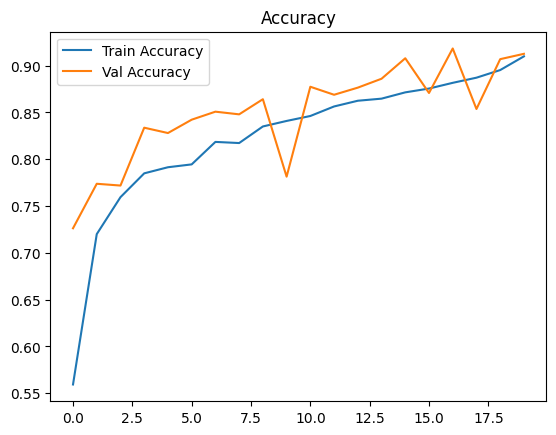

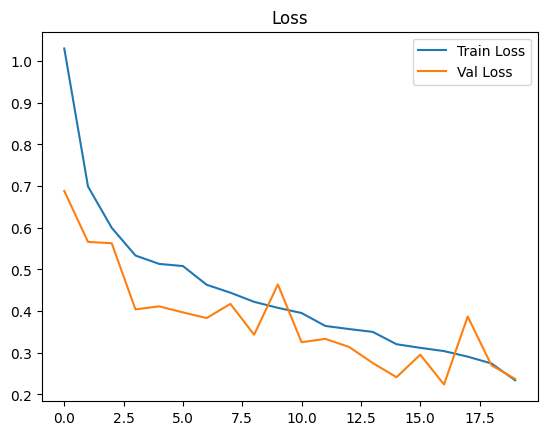

In [ ]:
# ==========================================================
# Plot Training History
# ==========================================================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure()
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

plt.figure()
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

In [ ]:
# ==========================================================
# Evaluation on Test Set
# ==========================================================
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))





1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━

              precision    recall  f1-score   support

      glioma       0.96      0.84      0.90       244
     healthy       0.97      0.96      0.96       300
  meningioma       0.82      0.87      0.84       248
   pituitary       0.93      0.99      0.96       265

    accuracy                           0.92      1057
   macro avg       0.92      0.92      0.92      1057
weighted avg       0.92      0.92      0.92      1057



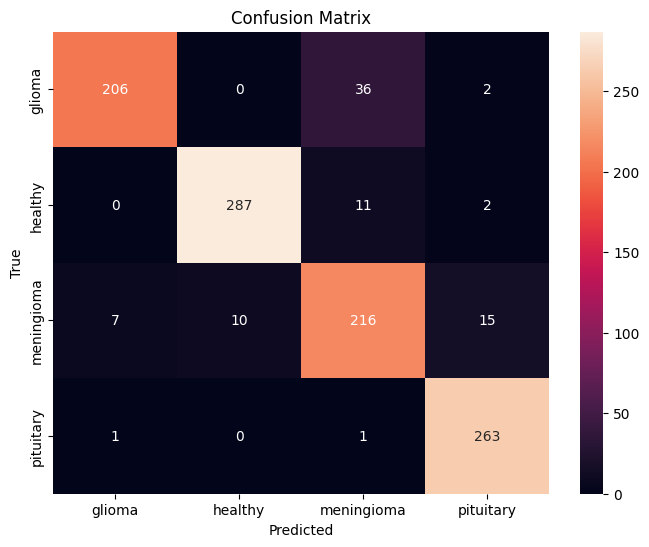

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import cv2

print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()